In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Load data

In [21]:
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025\processed_train.csv")
df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025\processed_test.csv")

In [22]:
columns_remove = [
    'VitaminD',
    'YearStart',
]

In [23]:
df_train = df_train[df_train['milk_consumption']<=3]
df_test = df_test[df_test['milk_consumption']<=3]

In [24]:
df_train.drop(columns=columns_remove, inplace=True)
df_test.drop(columns=columns_remove, inplace=True)

In [25]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'SmokeFam', 'milk_consumption',
       'label'],
      dtype='object')

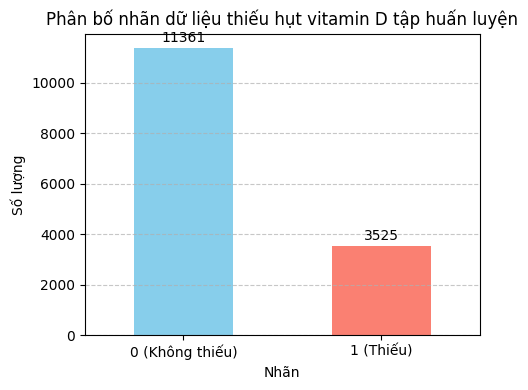

In [26]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_train['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Phân bố nhãn dữ liệu thiếu hụt vitamin D tập huấn luyện')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks(ticks=[0, 1], labels=['0 (Không thiếu)', '1 (Thiếu)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


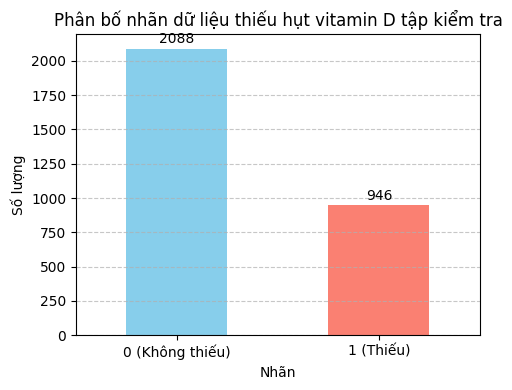

In [27]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_test['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Phân bố nhãn dữ liệu thiếu hụt vitamin D tập kiểm tra')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks(ticks=[0, 1], labels=['0 (Không thiếu)', '1 (Thiếu)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [28]:
category_columns = [
    'Gender','SmokeFam' ,'Race', 'label','milk_consumption'
]

# Model training and evaluation

In [29]:
unuseful_features = ['WaistCircumference','AST','ALT','AlkalinePhosphotase','UricAcid','LDLCholesterol','Hematocrit','MeanCellHemoglobin','PlateletCount', 'MeanPlateletVolume','familysize']

In [30]:
df_train.drop(columns=unuseful_features,inplace=True)
df_test = df_test[df_train.columns]

In [31]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'PIR', 'BMI', 'FastingGlucose',
       'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin',
       'MeanCellVolumn', 'RedCellDistributionWidth', 'SmokeFam',
       'milk_consumption', 'label'],
      dtype='object')

['Age', 'PIR', 'BMI', 'FastingGlucose', 'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth']
['Gender', 'Race', 'milk_consumption', 'SmokeFam']
🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8248, R=0.7079, F1=0.7619, Support=2088
Class 1: P=0.5089, R=0.6681, F1=0.5777, Support=946
✅ LightGBM - Accuracy: 0.6955, F1: 0.6698, AUC: 0.7366

🚀 Training: Naive Bayes


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Per-class metrics:
Class 0: P=0.8359, R=0.5000, F1=0.6257, Support=2088
Class 1: P=0.4151, R=0.7833, F1=0.5427, Support=946
✅ Naive Bayes - Accuracy: 0.5883, F1: 0.5842, AUC: 0.6985

⚡ Creating Manual Ensembles...

🔬 Testing Multiple Mathematical Ensemble Formulations...

🔬 Testing Extensive Weight Combinations...
✅ 50-50 Equal - Accuracy: 0.6124, F1: 0.6054, AUC: 0.7319
✅ 60-40 LGBM-NB - Accuracy: 0.6259, F1: 0.6166, AUC: 0.7347
✅ 70-30 LGBM-NB - Accuracy: 0.6447, F1: 0.6323, AUC: 0.7370
✅ 80-20 LGBM-NB - Accuracy: 0.6582, F1: 0.6420, AUC: 0.7385
✅ 81-19 LGBM-NB - Accuracy: 0.6618, F1: 0.6450, AUC: 0.7386
✅ 82-18 LGBM-NB - Accuracy: 0.6632, F1: 0.6459, AUC: 0.7386
✅ 83-17 LGBM-NB - Accuracy: 0.6648, F1: 0.6470, AUC: 0.7388
✅ 84-16 LGBM-NB - Accuracy: 0.6651, F1: 0.6468, AUC: 0.7388
✅ 85-15 LGBM-NB - Accuracy: 0.6671, F1: 0.6483, AUC: 0.7389
✅ 86-14 LGBM-NB - Accuracy: 0.6688, F1: 0.6496, AUC: 0.7389
✅ 87-13 LGBM-NB - Accuracy: 0.6704, F1: 0.6507, AUC: 0.7389
✅ 88-12 LGBM-NB - Accuracy

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_11128\1483004233.py:293: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()


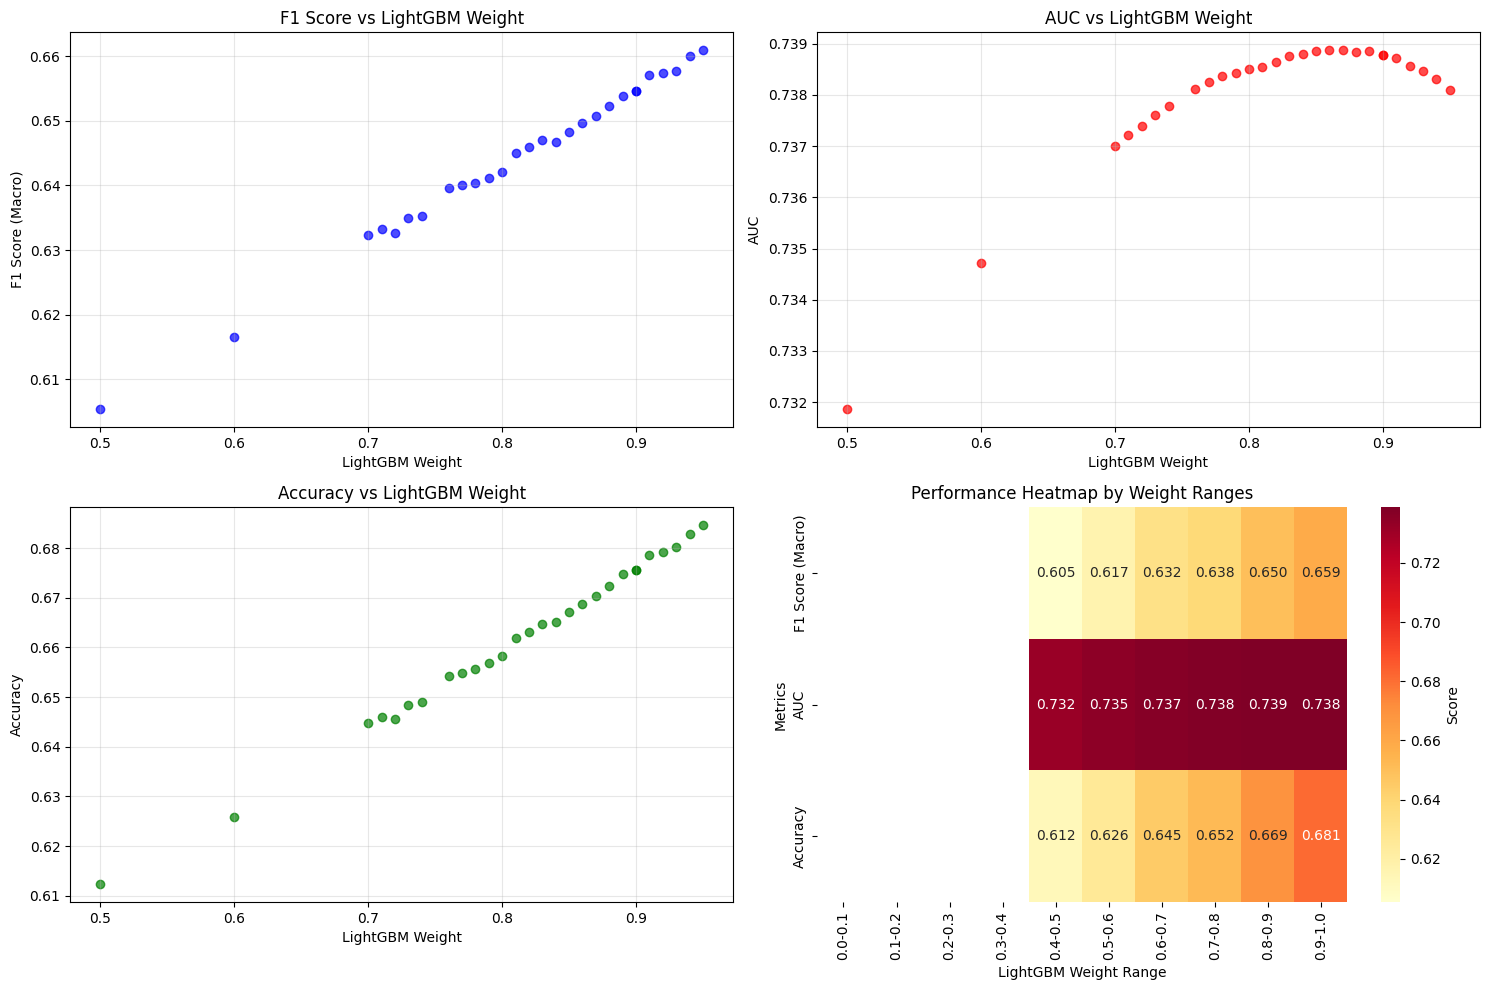


📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv

📊 FINAL RESULTS SUMMARY:
                 Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC  LGBM_Weight  NB_Weight
              LightGBM             0.6668          0.6880            0.6698    0.6955 0.7366          NaN        NaN
           Naive Bayes             0.6255          0.6416            0.5842    0.5883 0.6985          NaN        NaN
  Weighted 50-50 Equal             0.6347          0.6551            0.6054    0.6124 0.7319       0.5000     0.5000
Weighted 60-40 LGBM-NB             0.6386          0.6609            0.6166    0.6259 0.7347       0.6000     0.4000
Weighted 70-30 LGBM-NB             0.6463          0.6705            0.6323    0.6447 0.7370       0.7000     0.3000
Weighted 80-20 LGBM-NB             0.6494          0.6736            0.6420    0.6582 0.7385       0.8000     0.2000
Weighted 81-19 LGBM-NB             0.6513          0.6757            0.6450    0.6618 0.7386   

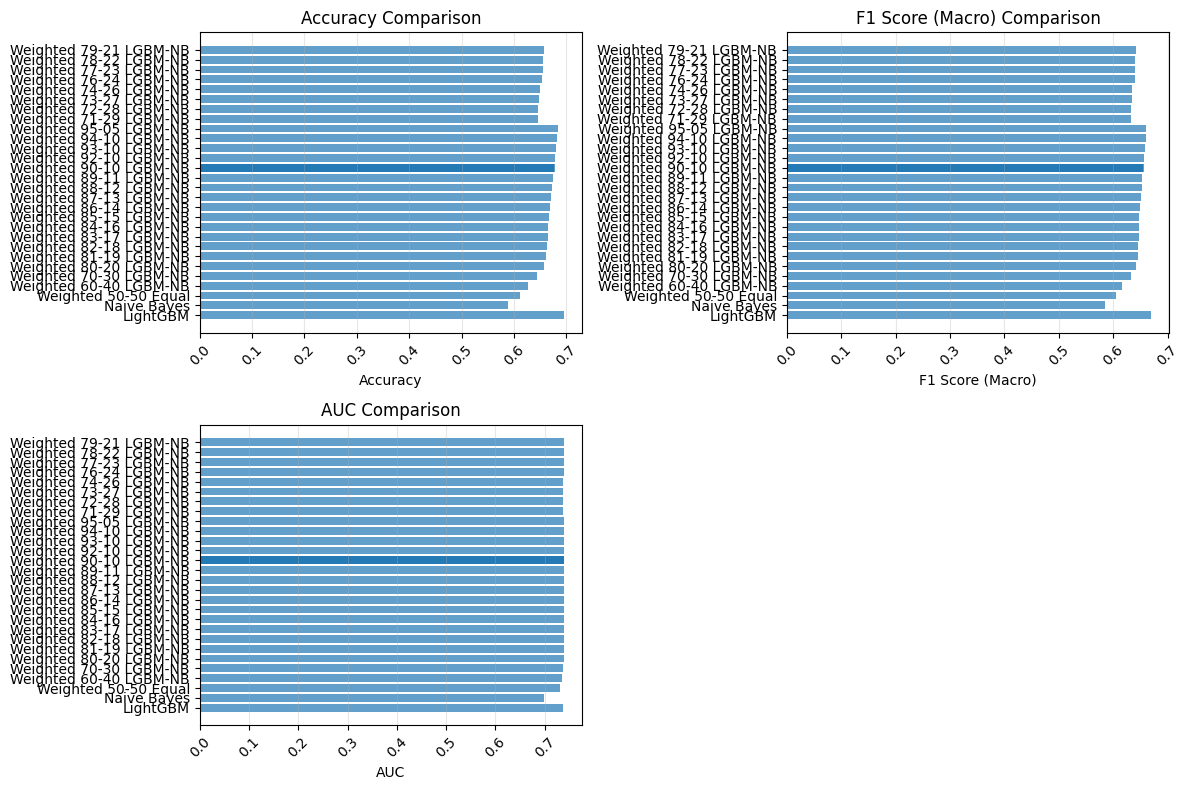


💡 Ensemble Tips:
- LightGBM typically handles complex patterns better
- Naive Bayes is fast and works well with small datasets
- Weighted average often performs better than equal weighting
- Test different weight combinations to find optimal balance


In [52]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

X_train_raw = df_train.drop(columns='label')
y_train=df_train['label']
X_test_raw=df_test.drop(columns=['label'])
y_test=df_test['label']
categorical_cols = ['Gender','Race', 'milk_consumption','SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']
print(numeric_cols)
print(categorical_cols)
# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', lgbm)
])

# ====== 2) Naive Bayes pipeline ======
nb = GaussianNB()

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

nb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', nb)
])
from xgboost import XGBClassifier

xgb = XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    )

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

xgb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', xgb)
])
# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
nb_wrapped = ImblearnWrapper(nb_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'Naive Bayes': nb_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        from sklearn.metrics import precision_recall_fscore_support

        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")

        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    
    # 🧮 MATHEMATICAL ENSEMBLE COMBINATION THEORIES 🧮
    print("\n🔬 Testing Multiple Mathematical Ensemble Formulations...")
    
    ensemble_formulations = []
    
    # Comprehensive weight testing
    print("\n🔬 Testing Extensive Weight Combinations...")
    weight_combinations = [
        # Standard combinations
        (0.5, 0.5, "50-50 Equal"),
        (0.6, 0.4, "60-40 LGBM-NB"),
        (0.7, 0.3, "70-30 LGBM-NB"),
        (0.8, 0.2, "80-20 LGBM-NB"),
        (0.81, 0.19, "81-19 LGBM-NB"),
        (0.82, 0.18, "82-18 LGBM-NB"),
        (0.83, 0.17, "83-17 LGBM-NB"),
        (0.84, 0.16, "84-16 LGBM-NB"),
        (0.85, 0.15, "85-15 LGBM-NB"),
        (0.86, 0.14, "86-14 LGBM-NB"),
        (0.87, 0.13, "87-13 LGBM-NB"),
        (0.88, 0.12, "88-12 LGBM-NB"),
        (0.89, 0.11, "89-11 LGBM-NB"),
        (0.9, 0.1, "90-10 LGBM-NB"),
        (0.9, 0.1, "90-10 LGBM-NB"),
        (0.91, 0.09, "90-10 LGBM-NB"),
        (0.92, 0.08, "92-10 LGBM-NB"),
        (0.93, 0.07, "93-10 LGBM-NB"),
        (0.94, 0.06, "94-10 LGBM-NB"),
        (0.95, 0.05, "95-05 LGBM-NB"),


        # Very fine-grained around optimal range (70-80% LGBM)
        (0.71, 0.29, "71-29 LGBM-NB"),
        (0.72, 0.28, "72-28 LGBM-NB"),
        (0.73, 0.27, "73-27 LGBM-NB"),
        (0.74, 0.26, "74-26 LGBM-NB"),
        (0.76, 0.24, "76-24 LGBM-NB"),
        (0.77, 0.23, "77-23 LGBM-NB"),
        (0.78, 0.22, "78-22 LGBM-NB"),
        (0.79, 0.21, "79-21 LGBM-NB"),
    ]
    
    # Store results for analysis
    weight_results = []
    
    for w1, w2, desc in weight_combinations:
        ensemble_proba_test = w1 * lgbm_proba + w2 * nb_proba
        y_pred_test = (ensemble_proba_test > 0.5).astype(int)
        
        f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
        accuracy_test = accuracy_score(y_test, y_pred_test)
        auc_test = roc_auc_score(y_test, ensemble_proba_test)
        precision_test = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
        recall_test = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
        
        result = {
            'Model': f'Weighted {desc}',
            'LGBM_Weight': w1,
            'NB_Weight': w2,
            'Precision (Macro)': precision_test,
            'Recall (Macro)': recall_test,
            'F1 Score (Macro)': f1_test,
            'Accuracy': accuracy_test,
            'AUC': auc_test
        }
        
        manual_results.append(result)
        weight_results.append(result)
        
        print(f"✅ {desc} - Accuracy: {accuracy_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")
    
    # Find optimal weights
    weight_results_df = pd.DataFrame(weight_results)
    
    # Best by different metrics
    best_f1_weight = weight_results_df.loc[weight_results_df['F1 Score (Macro)'].idxmax()]
    best_auc_weight = weight_results_df.loc[weight_results_df['AUC'].idxmax()]
    best_acc_weight = weight_results_df.loc[weight_results_df['Accuracy'].idxmax()]
    
    print(f"\n🎯 OPTIMAL WEIGHTS:")
    print(f"Best F1: LGBM={best_f1_weight['LGBM_Weight']:.2f}, NB={best_f1_weight['NB_Weight']:.2f} (F1: {best_f1_weight['F1 Score (Macro)']:.4f})")
    print(f"Best AUC: LGBM={best_auc_weight['LGBM_Weight']:.2f}, NB={best_auc_weight['NB_Weight']:.2f} (AUC: {best_auc_weight['AUC']:.4f})")
    print(f"Best Accuracy: LGBM={best_acc_weight['LGBM_Weight']:.2f}, NB={best_acc_weight['NB_Weight']:.2f} (Acc: {best_acc_weight['Accuracy']:.4f})")
    
    # Plot weight analysis
    plt.figure(figsize=(15, 10))
    
    # F1 Score vs LGBM Weight
    plt.subplot(2, 2, 1)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['F1 Score (Macro)'], alpha=0.7, c='blue')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('F1 Score (Macro)')
    plt.title('F1 Score vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # AUC vs LGBM Weight  
    plt.subplot(2, 2, 2)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['AUC'], alpha=0.7, c='red')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('AUC')
    plt.title('AUC vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Accuracy vs LGBM Weight
    plt.subplot(2, 2, 3)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['Accuracy'], alpha=0.7, c='green')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Combined metrics heatmap
    plt.subplot(2, 2, 4)
    # Create a simplified heatmap with binned weights
    weight_bins = np.arange(0, 1.1, 0.1)
    binned_weights = pd.cut(weight_results_df['LGBM_Weight'], weight_bins, labels=[f'{i:.1f}-{i+0.1:.1f}' for i in weight_bins[:-1]])
    heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()
    
    sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
    plt.title('Performance Heatmap by Weight Ranges')
    plt.xlabel('LightGBM Weight Range')
    plt.ylabel('Metrics')
    
    plt.tight_layout()
    plt.show()
    
    # Save detailed weight analysis
    weight_results_df.to_csv("weight_analysis_nb_lgbm.csv", index=False)
    print(f"\n📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("nb_lgbm_ensemble_results.csv", index=False)
print(f"\n✅ Results exported to: nb_lgbm_ensemble_results.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

# ====== 8) Plot model comparison ======
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'F1 Score (Macro)', 'AUC']
models = results_df['Model'].tolist()

# Create subplots for each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Filter out None values for AUC
    if metric == 'AUC':
        data = results_df[results_df[metric].notna()]
    else:
        data = results_df
    
    plt.barh(data['Model'], data[metric], alpha=0.7)
    plt.title(f'{metric} Comparison')
    plt.xlabel(metric)
    plt.grid(axis='x', alpha=0.3)
    
    # Rotate labels if needed
    if len(models) > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Ensemble Tips:")
print("- LightGBM typically handles complex patterns better")
print("- Naive Bayes is fast and works well with small datasets")
print("- Weighted average often performs better than equal weighting")
print("- Test different weight combinations to find optimal balance")

In [ ]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
✅ LightGBM - Accuracy: 0.6955, F1: 0.6698, AUC: 0.7366

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


✅ TabNet - Accuracy: 0.6691, F1: 0.6367, AUC: 0.6804

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6763, F1: 0.6568
✅ Weighted Average - Accuracy: 0.7024, F1: 0.6737, AUC: 0.7363
✅ Hybrid Rules - Accuracy: 0.7241, F1: 0.6785

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6668          0.6880            0.6698    0.6955 0.7366
            TabNet             0.6341          0.6486            0.6367    0.6691 0.6804
Threshold Ensemble             0.6590          0.6833            0.6568    0.6763    NaN
  Weighted Average             0.6696          0.6884            0.6737    0.7024 0.7363
      Hybrid Rules             0.6785          0.6784            0.6785    0.7241    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv

🏆 BEST MODEL: Hybrid Rules (F1 Score: 0.6785)


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [54]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8248, R=0.7079, F1=0.7619, Support=2088
Class 1: P=0.5089, R=0.6681, F1=0.5777, Support=946
✅ LightGBM - Accuracy: 0.6955, F1: 0.6698, AUC: 0.7366

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.7927, R=0.7031, F1=0.7452, Support=2088
Class 1: P=0.4755, R=0.5941, F1=0.5282, Support=946
✅ TabNet - Accuracy: 0.6691, F1: 0.6367, AUC: 0.6804

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6763, F1: 0.6568
✅ Weighted Average - Accuracy: 0.7024, F1: 0.6737, AUC: 0.7363
✅ Hybrid Rules - Accuracy: 0.7241, F1: 0.6785

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6668          0.6880            0.6698    0.6955 0.7366
            TabNet             0.6341          0.6486            0.6367    0.6691 0.6804
Threshold Ensemble             0.6590          0.6833            0.6568    0.6763    NaN
  Weighted Average             0.6696          0.6884            0.6737    0.7024 0.7363
      Hybrid Rules             0.6785          0.6784            0.6785    0.7241    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [55]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.8, 0.2
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8248, R=0.7079, F1=0.7619, Support=2088
Class 1: P=0.5089, R=0.6681, F1=0.5777, Support=946
✅ LightGBM - Accuracy: 0.6955, F1: 0.6698, AUC: 0.7366

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.7927, R=0.7031, F1=0.7452, Support=2088
Class 1: P=0.4755, R=0.5941, F1=0.5282, Support=946
✅ TabNet - Accuracy: 0.6691, F1: 0.6367, AUC: 0.6804

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6763, F1: 0.6568
✅ Weighted Average - Accuracy: 0.6971, F1: 0.6695, AUC: 0.7381
✅ Hybrid Rules - Accuracy: 0.7241, F1: 0.6785

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6668          0.6880            0.6698    0.6955 0.7366
            TabNet             0.6341          0.6486            0.6367    0.6691 0.6804
Threshold Ensemble             0.6590          0.6833            0.6568    0.6763    NaN
  Weighted Average             0.6659          0.6854            0.6695    0.6971 0.7381
      Hybrid Rules             0.6785          0.6784            0.6785    0.7241    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
